# Loans at Risk: Capturing Default — Exploratory Data Analysis

### Purpose

This notebook examines the LendingClub loan dataset to determine whether it provides a coherent representation of the lending process and whether the information available at loan application contains observable differences in borrower default outcomes.

Before predictive modeling can be performed, it is necessary to verify that loan outcomes are well defined, that the dataset supports a realistic temporal evaluation design, and that submission-time borrower and loan characteristics exhibit meaningful variation in default rates.

---

### Analytical Approach

The analysis proceeds in two stages.

The first stage evaluates the structural properties of the dataset using the **`clean` dataset**. This dataset retains the loan issue date (`issue_d`), allowing the analysis to examine the temporal evolution of the lending portfolio and verify that the data supports a realistic train–test evaluation design. Diagnostic checks assess loan outcome definitions, the distribution of loan issuance over time, and potential reporting shifts affecting several balance-related variables.

The second stage examines the submission-time feature space using the **`feature_base` dataset**. This dataset contains only variables observable at the moment of loan application and therefore suitable for predictive modeling. The loan issue date (`issue_d`) is excluded because it reflects the loan origination timestamp and would introduce information unavailable at prediction time.

Using this feature-base dataset, borrower credit history, leverage, repayment capacity, and loan structure variables are evaluated to determine whether they correspond to systematic differences in default rates.

---

### Scope

This notebook focuses on dataset diagnostics and submission-time feature exploration. It establishes the modeling population using realized repayment outcomes and evaluates whether borrower and loan characteristics observable at application correspond to differences in default risk.

Predictive modeling is not performed here. Model construction, performance evaluation, and comparison with LendingClub’s grading system are addressed in the subsequent stages of the project.

In [1]:
from pathlib import Path
import sys

current_path = Path.cwd().resolve()
project_root = None

for parent_path in (current_path, *current_path.parents):
    if (parent_path / "pyproject.toml").exists():
        project_root = parent_path
        break

if project_root is None:
    raise RuntimeError(
        f"Failed to resolve project root: pyproject.toml not found from {current_path}"
    )

src_path = project_root / "src"
if not src_path.exists():
    raise RuntimeError(f"Expected 'src' directory at: {src_path}")

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

{
    "stage": "bootstrap_import_path_ready",
    "project_root": str(project_root),
}


{'stage': 'bootstrap_import_path_ready',
 'project_root': 'D:\\Portfolio\\loans-at-risk-capturing-default'}

In [ ]:
# ============================================================================
# Imports: libraries and project modules
# ============================================================================

from datetime import datetime, timezone
from typing import Callable
import uuid

from IPython.display import display
import pandas as pd

import analysis.eda_artifacts as ea
import plots.eda_figures as eda_fig
import config.logging as log_config
import plots.report_figures as rf



In [3]:
# ===============================
# Paths and run context
# ===============================

logs_root = project_root / "logs"
logs_root.mkdir(parents=True, exist_ok=True)

PROJECT_LOG_FILE = logs_root / "project.log"

run_id = uuid.uuid4().hex[:10]
run_timestamp_utc = datetime.now(timezone.utc)

run_header = (
    "NEW RUN: "
    f"{run_timestamp_utc.strftime('%Y-%m-%d %H:%M:%S')} UTC | "
    f"RUN_ID={run_id}"
)

log_config.log_messages("\n" + "=" * 60, PROJECT_LOG_FILE)
log_config.log_messages(run_header, PROJECT_LOG_FILE)
log_config.log_messages("=" * 60 + "\n", PROJECT_LOG_FILE)

log: Callable[[str], None] = log_config.get_logger(PROJECT_LOG_FILE)
log("EDA notebook initialized")
log(f"project_root: {project_root}")
log(run_header)

{
    "stage": "run_started",
    "run_id": run_id,
    "utc_timestamp": run_timestamp_utc.isoformat(),
}

# ---------------------------------------------------------------
# Inputs for this notebook (interim, report)
# ---------------------------------------------------------------

clean_train_data_file = project_root / "data" / "interim" / "clean_loan_data_2007_2014.parquet"
clean_test_data_file = project_root / "data" / "interim" / "clean_loan_data_2015.parquet"

feature_base_train_data_file = project_root / "data" / "interim" / "feature_base_loan_data_2007_2014.parquet"
feature_base_test_data_file = project_root / "data" / "interim" / "feature_base_loan_data_2015.parquet"

artifacts_dir = project_root / "artifacts"
eda_artifacts_dir = artifacts_dir / "eda"
eda_tables_dir = eda_artifacts_dir / "tables"
eda_figures_dir = eda_artifacts_dir / "figures"

eda_tables_dir.mkdir(parents=True, exist_ok=True)
eda_figures_dir.mkdir(parents=True, exist_ok=True)

log(f"Clean train parquet path: {clean_train_data_file}")
log(f"Clean test parquet path: {clean_test_data_file}")
log(f"Feature base train parquet path: {feature_base_train_data_file}")
log(f"Feature base test parquet path: {feature_base_test_data_file}")
log(f"EDA tables directory: {eda_tables_dir}")
log(f"EDA figures directory: {eda_figures_dir}")


## Part 1 — Diagnostic Validation (`clean`)

This section evaluates outcome integrity, cohort definition, temporal structure, and reporting stability using the **clean training dataset** and **clean testing dataset**. The objective is to confirm that the outcome variable, temporal structure, and dataset composition behave coherently before any feature-level analysis begins.

The clean dataset retains the full loan record. That makes it the correct layer for validating repayment outcomes, defining the realized-outcome modeling cohort, and examining temporal diagnostics based on `issue_d`.


#### Dataset Overview

In [ ]:
# --------------------------------------------------------
# Load clean datasets + checkpoint
# --------------------------------------------------------

df_clean_train = pd.read_parquet(clean_train_data_file)
df_clean_test = pd.read_parquet(clean_test_data_file)

clean_overview_df = ea.build_dataset_overview(
    df_train=df_clean_train,
    df_test=df_clean_test,
)

display(clean_overview_df)
log(f"[clean] overview: {clean_overview_df.to_dict(orient='records')}")


,dataset_split,rows,columns,memory_mb
0,train,466287,90,279.26
1,test,421095,90,252.20


In [ ]:
# --------------------------------------------------------
# Add issue_year for temporal diagnostics
# --------------------------------------------------------

df_clean_train = ea.add_issue_year(
    df=df_clean_train,
    log=log,
)

df_clean_test = ea.add_issue_year(
    df=df_clean_test,
    log=log,
)

clean_year_summary_df = pd.DataFrame(
    [
        {
            "dataset_split": "train",
            "min_issue_year": int(df_clean_train["issue_year"].min()),
            "max_issue_year": int(df_clean_train["issue_year"].max()),
            "distinct_issue_years": int(df_clean_train["issue_year"].nunique()),
        },
        {
            "dataset_split": "test",
            "min_issue_year": int(df_clean_test["issue_year"].min()),
            "max_issue_year": int(df_clean_test["issue_year"].max()),
            "distinct_issue_years": int(df_clean_test["issue_year"].nunique()),
        },
    ]
)

display(clean_year_summary_df)
log(f"[clean][issue_year] summary: {clean_year_summary_df.to_dict(orient='records')}")


,dataset_split,min_issue_year,max_issue_year,distinct_issue_years
0,train,2007,2014,8
1,test,2015,2015,1


#### Outcome distribution by vintage

The table is more useful here than a stacked bar chart. The question is not visual composition for its own sake. The question is whether outcome composition shifts across issuance years in a way that affects cohort definition and label maturity.

Early vintages are dominated by realized repayment outcomes. Later periods contain a larger share of loans whose repayment process had not yet concluded at the moment of extraction. That difference must be handled before modeling.


In [ ]:
# --------------------------------------------------------
# Outcome distribution by issue year
# --------------------------------------------------------

loan_status_by_year_train_df = ea.build_loan_status_by_issue_year_table(
    df=df_clean_train,
)

loan_status_by_year_test_df = ea.build_loan_status_by_issue_year_table(
    df=df_clean_test,
)

loan_status_by_year_combined_df = ea.build_split_table(
    df_train=loan_status_by_year_train_df,
    df_test=loan_status_by_year_test_df,
    index_name="issue_year",
)

display(loan_status_by_year_combined_df)

loan_status_by_year_artifact_file = eda_tables_dir / "clean_loan_status_by_issue_year.csv"
loan_status_by_year_combined_df.to_csv(loan_status_by_year_artifact_file)

{
    "stage": "clean_loan_status_by_issue_year_saved",
    "path": str(loan_status_by_year_artifact_file),
    "rows": int(loan_status_by_year_combined_df.shape[0]),
}


loan_status               charged_off  current  default  \
dataset_split issue_year                                  
train         2007                 45        0        0   
              2008                247        0        0   
              2009                594        0        0   
              2010               1487        0        0   
              2011               3280      513        1   
              2012               8317     2768       17   
              2013              17238    37184       27   
              2014              21266   133113       66   
test          2015              11075   346702       93   

loan_status               does_not_meet_the_credit_policy._status:charged_off  \
dataset_split issue_year                                                        
train         2007                                                      113     
              2008                                                      249     
              2009                                                      129     
              2010                                                      270     
              2011                                                        0     
              2012                                                        0     
              2013                                                        0     
              2014                                                        0     
test          2015                                                        0     

loan_status               does_not_meet_the_credit_policy._status:fully_paid  \
dataset_split issue_year                                                       
train         2007                                                      239    
              2008                                                      582    
              2009                                                      436    
              2010                                                      731    
              2011                                                        0    
              2012                                                        0    
              2013                                                        0    
              2014                                                        0    
test          2015                                                        0    

loan_status               fully_paid  in_grace_period  late_(16-30_days)  \
dataset_split issue_year                                                   
train         2007               206                0                  0   
              2008              1315                0                  0   
              2009              4122                0                  0   
              2010             10049                0                  0   
              2011             17894               16                  5   
              2012             42051               98                 19   
              2013             78069              890                268   
              2014             73905             2522                817   
test          2015             48844             5122               1711   

loan_status               late_(31-120_days)  
dataset_split issue_year                      
train         2007                         0  
              2008                         0  
              2009                         0  
              2010                         0  
              2011                        12  
              2012                        97  
              2013                      1080  
              2014                      3940  
test          2015                      7548

{'stage': 'clean_loan_status_by_issue_year_saved',
 'path': 'D:\\Portfolio\\loans-at-risk-capturing-default\\artifacts\\eda\\tables\\clean_loan_status_by_issue_year.csv',
 'rows': 9}

#### Realized-outcome cohort definition

The modeling population is defined by excluding loans whose repayment outcome has not yet been determined. This removes censoring from the label and restricts the analysis to loans where borrower behavior is fully observed.

The resulting cohort is the relevant base for both later feature analysis and downstream modeling.


In [ ]:
# --------------------------------------------------------
# Realized-outcome cohort definition
# --------------------------------------------------------

terminal_statuses_final = [
    "fully_paid",
    "charged_off",
    "default",
]

positive_statuses = [
    "charged_off",
    "default",
]

df_clean_train_terminal = ea.build_terminal_cohort(
    df=df_clean_train,
    status_column="loan_status",
    terminal_statuses=terminal_statuses_final,
    positive_statuses=positive_statuses,
    target_column="target_default",
    log=log,
)

df_clean_test_terminal = ea.build_terminal_cohort(
    df=df_clean_test,
    status_column="loan_status",
    terminal_statuses=terminal_statuses_final,
    positive_statuses=positive_statuses,
    target_column="target_default",
    log=log,
)

clean_terminal_summary_df = ea.build_terminal_cohort_summary(
    df_train=df_clean_train_terminal,
    df_test=df_clean_test_terminal,
)

display(clean_terminal_summary_df)
log(f"[clean][terminal_cohort] summary: {clean_terminal_summary_df.to_dict(orient='records')}")


,dataset_split,rows,columns,default_rate_percent,positive_count,negative_count,status_count_fully_paid,status_count_charged_off,status_count_default
0,train,280196,92,18.77,52585,227611,227611,52474,111
1,test,60012,92,18.61,11168,48844,48844,11075,93


#### Temporal Outcome Dynamics

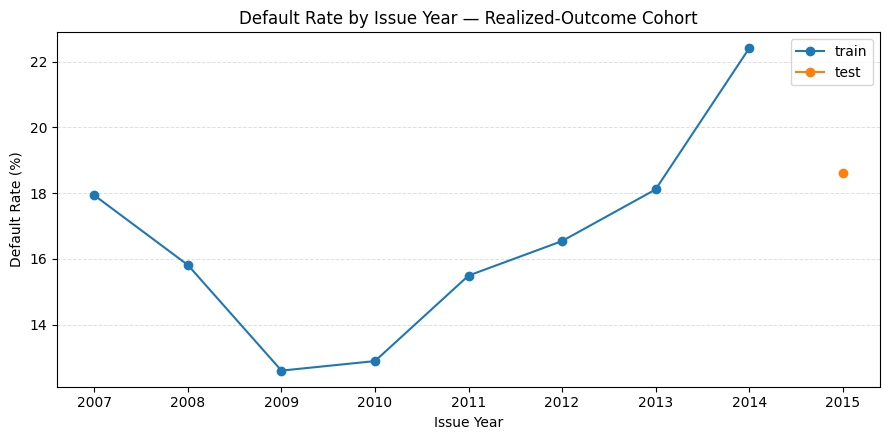

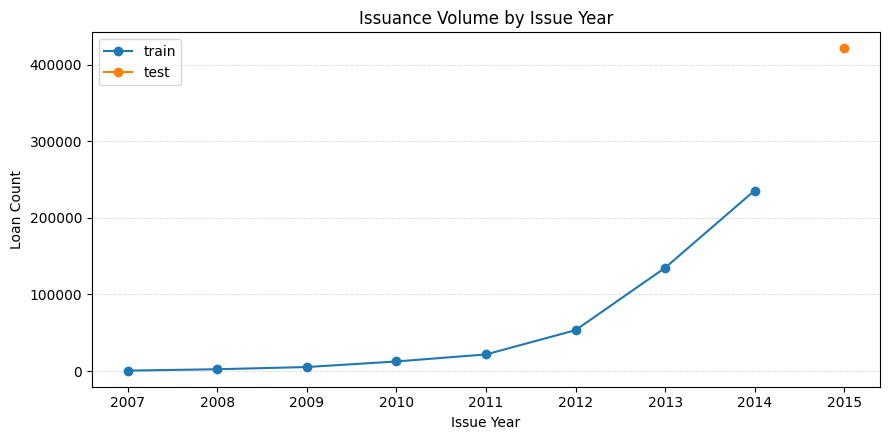

{'default_rate_by_issue_year_file': 'D:\\Portfolio\\loans-at-risk-capturing-default\\artifacts\\eda\\tables\\clean_default_rate_by_issue_year.csv',
 'issuance_volume_by_issue_year_file': 'D:\\Portfolio\\loans-at-risk-capturing-default\\artifacts\\eda\\tables\\clean_issuance_volume_by_issue_year.csv'}

In [ ]:
# --------------------------------------------------------
# Temporal outcome dynamics
# --------------------------------------------------------

default_rate_by_year_train_df = ea.build_default_rate_by_issue_year(
    df=df_clean_train_terminal,
    dataset_split="train",
)

default_rate_by_year_test_df = ea.build_default_rate_by_issue_year(
    df=df_clean_test_terminal,
    dataset_split="test",
)

default_rate_by_year_df = pd.concat(
    [default_rate_by_year_train_df, default_rate_by_year_test_df],
    axis=0,
    ignore_index=True,
)

issuance_volume_by_year_train_df = ea.build_issuance_volume_by_issue_year(
    df=df_clean_train,
    dataset_split="train",
)

issuance_volume_by_year_test_df = ea.build_issuance_volume_by_issue_year(
    df=df_clean_test,
    dataset_split="test",
)

issuance_volume_by_year_df = pd.concat(
    [issuance_volume_by_year_train_df, issuance_volume_by_year_test_df],
    axis=0,
    ignore_index=True,
)


eda_fig.plot_line_comparison(
    default_rate_by_year_df,
    x_column="issue_year",
    y_column="default_rate_percent",
    split_column="dataset_split",
    title="Default Rate by Issue Year — Realized-Outcome Cohort",
    xlabel="Issue Year",
    ylabel="Default Rate (%)",
)

eda_fig.plot_line_comparison(
    issuance_volume_by_year_df,
    x_column="issue_year",
    y_column="loan_count",
    split_column="dataset_split",
    title="Issuance Volume by Issue Year",
    xlabel="Issue Year",
    ylabel="Loan Count",
)

default_rate_by_year_file = eda_tables_dir / "clean_default_rate_by_issue_year.csv"
default_rate_by_year_df.to_csv(default_rate_by_year_file, index=False)

issuance_volume_by_year_file = eda_tables_dir / "clean_issuance_volume_by_issue_year.csv"
issuance_volume_by_year_df.to_csv(issuance_volume_by_year_file, index=False)

{
    "default_rate_by_issue_year_file": str(default_rate_by_year_file),
    "issuance_volume_by_issue_year_file": str(issuance_volume_by_year_file),
}


#### Reporting Stability by Vintage

,dataset_split,feature_name,min_missing_percent,max_missing_percent
0,train,tot_coll_amt,0.0,100.0
1,train,tot_cur_bal,0.0,100.0
2,train,total_rev_hi_lim,0.0,100.0
3,test,tot_coll_amt,0.0,0.0
4,test,tot_cur_bal,0.0,0.0
5,test,total_rev_hi_lim,0.0,0.0


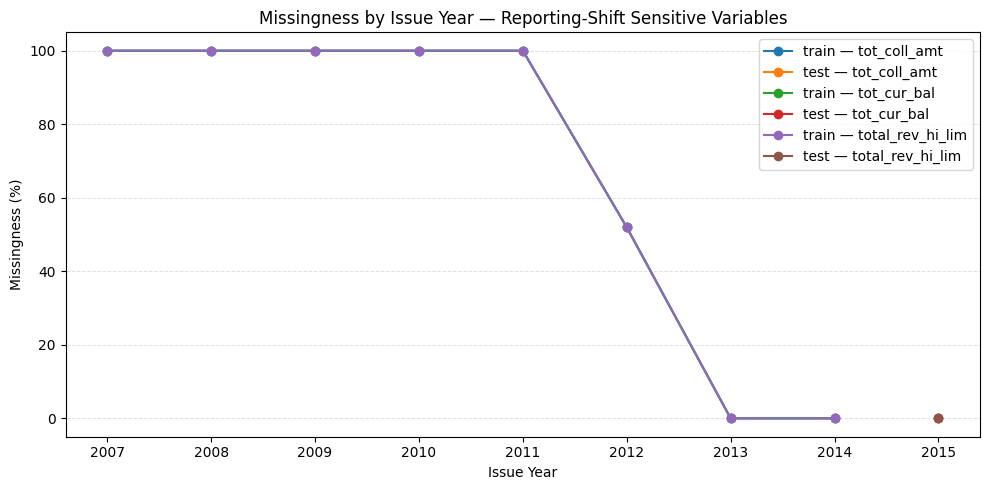

In [ ]:
# --------------------------------------------------------
# Reporting stability assessment
# --------------------------------------------------------

reporting_shift_columns = [
    "tot_coll_amt",
    "tot_cur_bal",
    "total_rev_hi_lim",
]

missingness_by_year_train_df = ea.build_missingness_by_issue_year(
    df=df_clean_train,
    column_names=reporting_shift_columns,
    dataset_split="train",
)

missingness_by_year_test_df = ea.build_missingness_by_issue_year(
    df=df_clean_test,
    column_names=reporting_shift_columns,
    dataset_split="test",
)

missingness_by_year_df = pd.concat(
    [missingness_by_year_train_df, missingness_by_year_test_df],
    axis=0,
    ignore_index=True,
)

reporting_shift_summary_df = (
    missingness_by_year_df
    .groupby(["dataset_split", "feature_name"], as_index=False)
    .agg(
        min_missing_percent=("missing_percent", "min"),
        max_missing_percent=("missing_percent", "max"),
    )
)

reporting_shift_summary_df["dataset_split"] = pd.Categorical(
    reporting_shift_summary_df["dataset_split"],
    categories=["train", "test"],
    ordered=True,
)

reporting_shift_summary_df = reporting_shift_summary_df.sort_values(
    ["dataset_split", "feature_name"]
).reset_index(drop=True)

display(reporting_shift_summary_df)

reporting_shift_series_order = [
    f"{dataset_split} — {feature_name}"
    for feature_name in reporting_shift_columns
    for dataset_split in ["train", "test"]
]

eda_fig.plot_multi_series_line_chart(
    missingness_by_year_df,
    x_column="issue_year",
    y_column="missing_percent",
    series_column="series_label",
    series_order=reporting_shift_series_order,
    title="Missingness by Issue Year — Reporting-Shift Sensitive Variables",
    xlabel="Issue Year",
    ylabel="Missingness (%)",
)

reporting_shift_file = eda_tables_dir / "clean_reporting_shift_summary.csv"
reporting_shift_summary_df.to_csv(reporting_shift_file, index=False)

log(f"[clean][reporting_shift] rows={missingness_by_year_df.shape[0]}")

#### Structural Boundary Confirmation

total_pymnt  total_rec_prncp  recoveries  out_prncp
dataset_split loan_status                                                     
train         charged_off      7401.57          3856.83     1078.64       0.00
              default         12477.19          8624.45        0.00    6950.32
              fully_paid      15593.30         13351.12        0.00       0.00
test          charged_off      3215.88          1435.15      664.68       0.00
              default          3941.21          2578.01        0.00   12365.54
              fully_paid      15469.11         14453.90        0.00       0.00

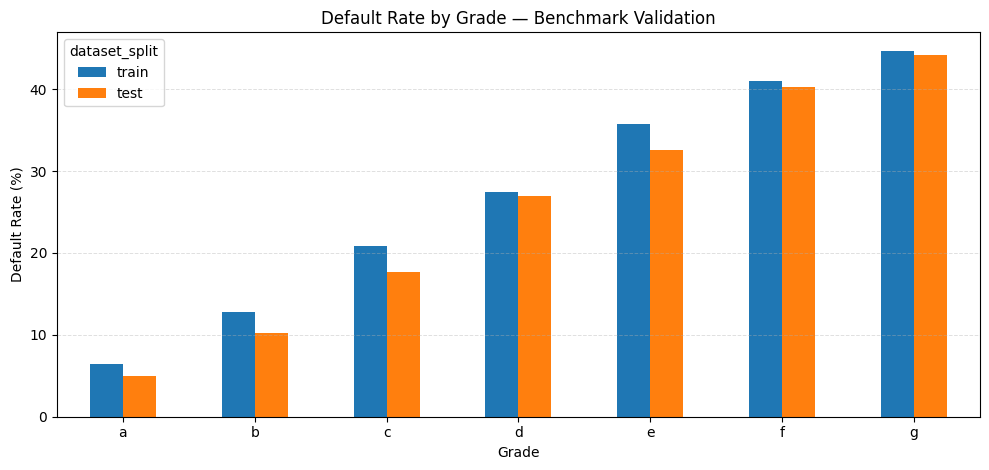

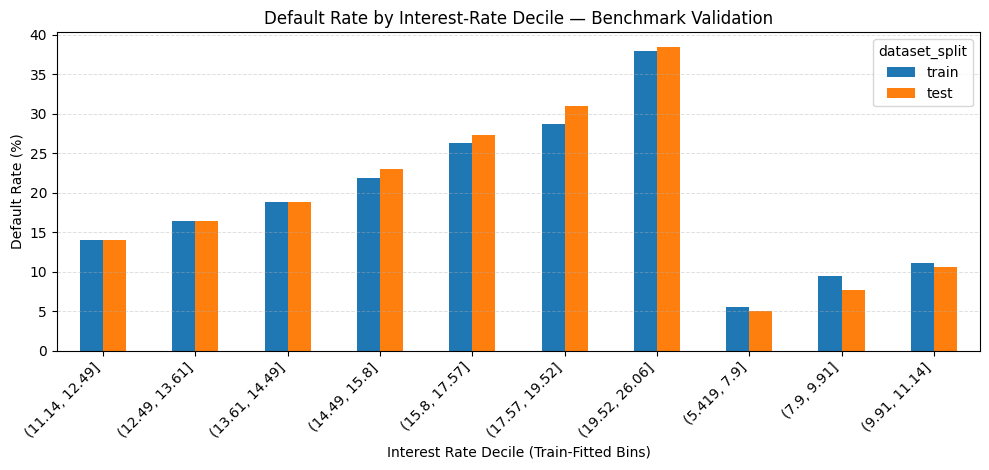

In [ ]:
# --------------------------------------------------------
# Structural boundary confirmation
# --------------------------------------------------------

benchmark_cashflow_columns = [
    "total_pymnt",
    "total_rec_prncp",
    "recoveries",
    "out_prncp",
]

cashflow_coherence_train_df = ea.build_group_mean_table(
    df=df_clean_train_terminal,
    group_column="loan_status",
    value_columns=benchmark_cashflow_columns,
)

cashflow_coherence_test_df = ea.build_group_mean_table(
    df=df_clean_test_terminal,
    group_column="loan_status",
    value_columns=benchmark_cashflow_columns,
)

cashflow_coherence_combined_df = ea.build_split_table(
    df_train=cashflow_coherence_train_df,
    df_test=cashflow_coherence_test_df,
    index_name="loan_status",
)

display(cashflow_coherence_combined_df)

default_rate_by_grade_df = ea.build_default_rate_by_category_comparison(
    df_train=df_clean_train_terminal,
    df_test=df_clean_test_terminal,
    feature_name="grade",
)

eda_fig.plot_default_rate_comparison(
    default_rate_by_grade_df,
    category_column="grade",
    title="Default Rate by Grade — Benchmark Validation",
    xlabel="Grade",
)

int_rate_decile_df = ea.build_default_rate_by_train_fitted_quantile(
    df_train=df_clean_train_terminal,
    df_test=df_clean_test_terminal,
    feature_name="int_rate",
    number_of_bins=10,
)

eda_fig.plot_default_rate_comparison(
    int_rate_decile_df,
    category_column="feature_bin",
    title="Default Rate by Interest-Rate Decile — Benchmark Validation",
    xlabel="Interest Rate Decile (Train-Fitted Bins)",
    rotate_labels=True,
)

benchmark_validation_file = eda_tables_dir / "clean_benchmark_validation.csv"
pd.concat(
    [
        default_rate_by_grade_df.rename(columns={"grade": "feature_bin"}),
        int_rate_decile_df,
    ],
    axis=0,
    ignore_index=True,
).to_csv(benchmark_validation_file, index=False)

benchmark_validation_artifact_metadata = {
    "benchmark_validation_file": str(benchmark_validation_file),
}


#### 1.6 Diagnostic summary

The clean dataset confirms three key properties of the lending process representation:

- 1. the outcome variable behaves coherently once non-realized repayment states are excluded. Loans that have completed their repayment cycle fall clearly into repayment or default outcomes, allowing the modeling cohort to be defined using realized borrower behavior.

- 2. the temporal structure of the dataset is consistent with the growth of the lending platform. Loan issuance expands over time while default rates remain broadly stable, supporting the evaluation design in which models are trained on earlier lending cohorts and evaluated on a later period.

- 3. several balance-related variables exhibit a reporting shift in the early years of the platform. These fields show systematic missingness during the earlier cohorts but become consistently populated in later years. This pattern reflects changes in reporting practices rather than borrower behavior and must therefore be treated as a data-quality artifact during modeling.

Taken together, these diagnostics indicate that the dataset provides a stable and interpretable observation of the lending process.

---

#### Outcome Definition and Event Balance

The modeling population is restricted to loans with a realized repayment outcome. Loans that remain active or are in intermediate repayment states (e.g., *current*, *grace period*, or *late*) are excluded because their final credit outcome is not yet observed. Loans labeled *does not meet the credit policy* are collapsed into their corresponding economic outcomes (*charged off* or *fully paid*), ensuring that all observations reflect realized borrower behavior.

After applying these definitions, the modeling population contains **64,514 default events** and **278,443 non-default events**, for a total of **342,957 loans**.

The resulting event rate is:

Event rate = 64,514 / 342,957 ≈ **18.8%**

Methodological guidance in predictive modeling commonly recommends a minimum number of outcome events relative to the number of predictors used in a logistic regression model. A widely cited rule-of-thumb is the **events-per-variable (EPV) criterion**, which suggests approximately **10 outcome events per predictor parameter** to obtain stable coefficient estimates (Peduzzi et al., 1996; Harrell, 2015). Subsequent research has shown that this threshold may in some cases be relaxed, but it remains a useful conservative guideline for assessing sample adequacy (Vittinghoff & McCulloch, 2007).

With **64,514 observed default events**, the dataset provides orders of magnitude more outcome events than required for the number of predictors used in this study. The modeling population therefore satisfies widely accepted minimum sample size requirements for predictive modeling.

With the integrity of the dataset established and the modeling population confirmed to contain a sufficient number of outcome events, the analysis can now move to the submission-time feature space used for model development.

---

## Part 1 — Conclusion

The diagnostic stage confirms that the dataset provides a coherent view of the lending process and that the modeling population can be defined clearly. Loans that have completed their repayment cycle fall into two observable outcomes: repayment or default, allowing the modeling cohort to be defined using realized borrower behavior rather than intermediate loan states.

The dataset’s temporal structure is also consistent with the growth of the lending platform. Loan issuance increases substantially over time while default rates remain broadly stable. This supports the evaluation design used in this project: models are trained on earlier lending cohorts and evaluated on a later period, allowing predictive performance to be measured under realistic out-of-sample conditions.

The analysis also identifies a reporting shift affecting several balance-related variables. These fields contain systematic missing values in the earlier years but become consistently populated in the test period. This pattern reflects a change in reporting practices rather than borrower behavior. Documenting this shift prevents the modeling stage from mistakenly interpreting reporting artifacts as predictive signal.

With unresolved loan states excluded, the resulting modeling population contains a large number of realized default events, ensuring that the dataset is statistically suitable for predictive modeling.

Taken together, these diagnostics indicate that the dataset provides a stable and interpretable record of the lending process. The outcome definition is clear, the temporal structure supports meaningful evaluation, and potential reporting artifacts have been identified. With these issues addressed, the analysis can move to the submission-time feature space to examine whether borrower characteristics contain signals relevant to credit risk.

---

## Part 2 — Decision-Focused Analysis (`feature_base`)

This section analyzes the submission-time feature space used for modeling. The **feature base training dataset** and **feature base testing dataset** contain only variables that satisfy the application-submission prediction boundary.

The feature base dataset does **not** retain `issue_d`. Temporal diagnostics therefore stop here. From this point onward the analysis is strictly cross-sectional: borrower profile, contract terms, balance-sheet burden, credit history, recent credit behavior, and reporting-shift-sensitive fields are evaluated only through information available at application.


#### Feature-Base Dataset Overview

In [ ]:
# --------------------------------------------------------
# Load feature base datasets + checkpoint
# --------------------------------------------------------

df_feature_base_train = pd.read_parquet(feature_base_train_data_file)
df_feature_base_test = pd.read_parquet(feature_base_test_data_file)

feature_base_overview_df = ea.build_dataset_overview(
    df_train=df_feature_base_train,
    df_test=df_feature_base_test,
)

display(feature_base_overview_df)
log(f"[feature_base] overview: {feature_base_overview_df.to_dict(orient='records')}")


,dataset_split,rows,columns,memory_mb
0,train,466287,66,206.33
1,test,421095,66,186.34


#### Realized-Outcome Cohort in Feature Base

In [ ]:
# --------------------------------------------------------
# Build terminal cohort for feature-space analysis
# --------------------------------------------------------

df_feature_base_train_terminal = ea.build_terminal_cohort(
    df=df_feature_base_train,
    status_column="loan_status",
    terminal_statuses=terminal_statuses_final,
    positive_statuses=positive_statuses,
    target_column="target_default",
    log=log,
)

df_feature_base_test_terminal = ea.build_terminal_cohort(
    df=df_feature_base_test,
    status_column="loan_status",
    terminal_statuses=terminal_statuses_final,
    positive_statuses=positive_statuses,
    target_column="target_default",
    log=log,
)

feature_base_terminal_summary_df = ea.build_terminal_cohort_summary(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
)

display(feature_base_terminal_summary_df)
log(f"[feature_base][terminal_cohort] summary: {feature_base_terminal_summary_df.to_dict(orient='records')}")


,dataset_split,rows,columns,default_rate_percent,positive_count,negative_count,status_count_fully_paid,status_count_charged_off,status_count_default
0,train,280196,67,18.77,52585,227611,227611,52474,111
1,test,60012,67,18.61,11168,48844,48844,11075,93


#### Feature Group Coverage Audit

In [ ]:
# --------------------------------------------------------
# Feature groups and coverage audit
# --------------------------------------------------------

feature_groups = {
    "target_definition_and_cohort": [
        "loan_status",
        "target_default",
    ],
    "application_profile": [
        "annual_inc",
        "home_ownership",
        "emp_length_years",
    ],
    "loan_structure": [
        "loan_amnt",
        "term_months",
        "purpose",
    ],
    "debt_burden": [
        "dti",
        "revol_util",
        "revol_bal",
        "tot_cur_bal",
        "tot_coll_amt",
        "total_rev_hi_lim",
    ],
    "credit_history": [
        "earliest_cr_line",
        "open_acc",
        "total_acc",
        "delinq_2yrs",
        "pub_rec",
        "collections_12_mths_ex_med",
        "acc_now_delinq",
    ],
    "recent_credit_behavior": [
        "inq_last_6mths",
        "mths_since_last_delinq",
        "mths_since_last_major_derog",
        "mths_since_last_record",
        "has_mths_since_last_delinq",
        "has_mths_since_last_major_derog",
        "has_mths_since_last_record",
    ],
    "reporting_shifts_data_quality": [
        "tot_coll_amt_missing",
        "tot_cur_bal_missing",
        "total_rev_hi_lim_missing",
    ],
}

feature_group_audit_train = ea.build_feature_group_audit(
    df=df_feature_base_train_terminal,
    feature_groups=feature_groups,
)

feature_group_audit_test = ea.build_feature_group_audit(
    df=df_feature_base_test_terminal,
    feature_groups=feature_groups,
)

feature_group_coverage_summary_df = pd.concat(
    [
        feature_group_audit_train["coverage_summary"].assign(dataset_split="train"),
        feature_group_audit_test["coverage_summary"].assign(dataset_split="test"),
    ],
    axis=0,
    ignore_index=True,
)

feature_group_coverage_summary_df = feature_group_coverage_summary_df[
    [
        "dataset_split",
        "feature_group",
        "grouped_feature_count",
        "present_feature_count",
        "missing_feature_count",
    ]
]

feature_group_coverage_summary_df["dataset_split"] = pd.Categorical(
    feature_group_coverage_summary_df["dataset_split"],
    categories=["train", "test"],
    ordered=True,
)

feature_group_coverage_summary_df = feature_group_coverage_summary_df.sort_values(
    ["dataset_split", "feature_group"]
).reset_index(drop=True)

display(feature_group_coverage_summary_df)

feature_group_audit_file = eda_tables_dir / "feature_group_audit.csv"
pd.concat(
    [
        feature_group_audit_train["coverage_summary"].assign(
            dataset_split="train",
            table_name="coverage_summary",
        ),
        feature_group_audit_test["coverage_summary"].assign(
            dataset_split="test",
            table_name="coverage_summary",
        ),
        feature_group_audit_train["feature_group_summary"].assign(
            dataset_split="train",
            table_name="feature_group_summary",
        ),
        feature_group_audit_test["feature_group_summary"].assign(
            dataset_split="test",
            table_name="feature_group_summary",
        ),
    ],
    axis=0,
    ignore_index=True,
).to_csv(feature_group_audit_file, index=False)

log(
    "[feature_base][feature_group_audit] "
    f"train_duplicate_grouped_columns={len(feature_group_audit_train['duplicate_grouped_columns'])} | "
    f"test_duplicate_grouped_columns={len(feature_group_audit_test['duplicate_grouped_columns'])} | "
    f"train_ungrouped_columns_count={len(feature_group_audit_train['ungrouped_columns'])} | "
    f"test_ungrouped_columns_count={len(feature_group_audit_test['ungrouped_columns'])}"
)


,dataset_split,feature_group,grouped_feature_count,present_feature_count,missing_feature_count
0,train,application_profile,3,3,0
1,train,credit_history,7,6,1
2,train,debt_burden,6,6,0
3,train,loan_structure,3,3,0
4,train,recent_credit_behavior,7,7,0
5,train,reporting_shifts_data_quality,3,0,3
6,train,target_definition_and_cohort,2,2,0
7,test,application_profile,3,3,0
8,test,credit_history,7,6,1
9,test,debt_burden,6,6,0


### 2.1 Target Definition & Cohort

The feature base dataset uses the same realized-outcome restriction as the clean dataset. This keeps the label definition consistent while limiting the analysis to variables that were available at application submission.

At this stage the relevant question is not temporal drift by issuance date. The relevant question is whether the submission-time feature space is examined on the same realized-outcome population defined earlier.


In [14]:
# --------------------------------------------------------
# Target behavior inside feature_base
# --------------------------------------------------------

baseline_default_rate_df = feature_base_terminal_summary_df[
    ["dataset_split", "rows", "default_rate_percent", "positive_count", "negative_count"]
].copy()

display(baseline_default_rate_df)

feature_base_target_summary_file = eda_tables_dir / "feature_base_target_summary.csv"
baseline_default_rate_df.to_csv(feature_base_target_summary_file, index=False)

feature_base_target_summary_artifact_metadata = {
    "feature_base_target_summary_file": str(feature_base_target_summary_file),
    "target_column_present_in_train": "target_default" in df_feature_base_train_terminal.columns,
    "target_column_present_in_test": "target_default" in df_feature_base_test_terminal.columns,
}


,dataset_split,rows,default_rate_percent,positive_count,negative_count
0,train,280196,18.77,52585,227611
1,test,60012,18.61,11168,48844


### 2.2 Application Profile

Application-profile variables describe the borrower at the moment of application. The relevant question is whether these fields separate repayment risk in a way that is both economically interpretable and stable across splits.


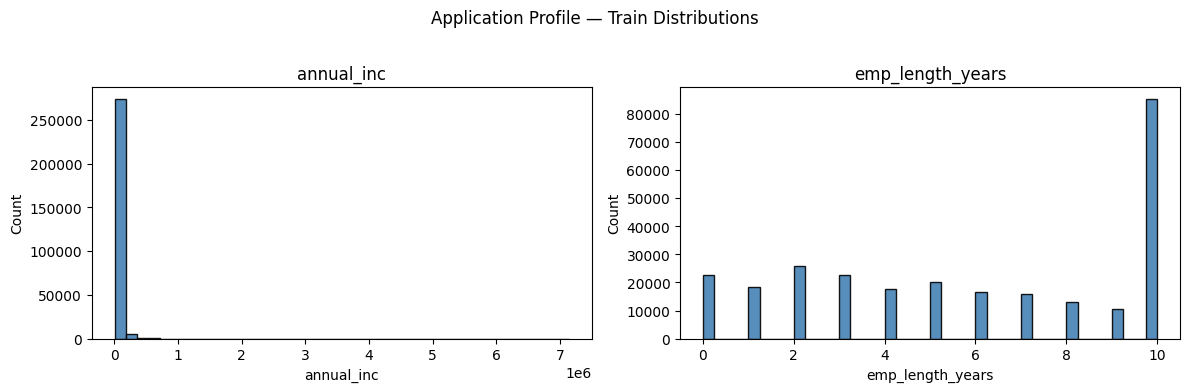

,feature_name,dataset_split,count,missing_percent,mean,median,p05,p95
0,annual_inc,train,280196,0.0,72323.21,62000.0,27900.0,148000.0
1,annual_inc,test,60012,0.0,77250.53,65000.0,29000.0,156000.0


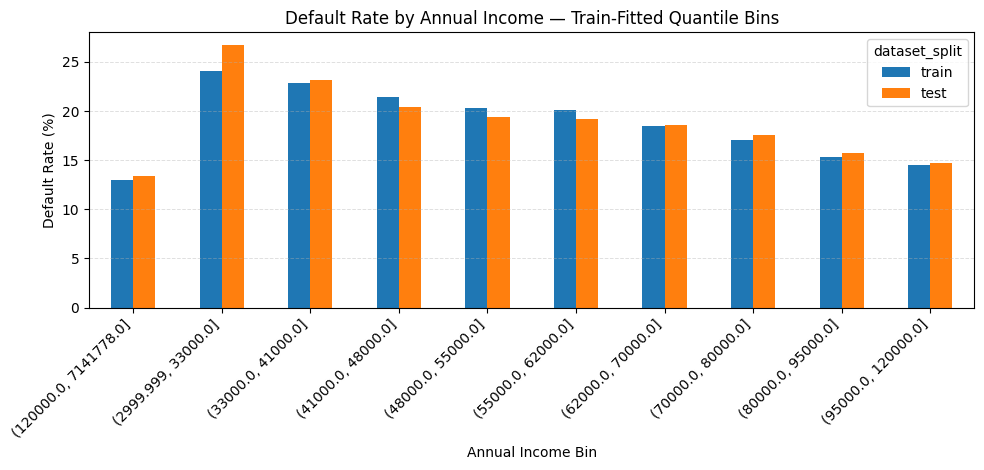

,feature_name,dataset_split,home_ownership,loan_count,default_rate_percent
0,home_ownership,train,mortgage,139019,16.82
1,home_ownership,train,other,185,18.38
2,home_ownership,train,own,23727,19.81
3,home_ownership,train,rent,117265,20.86
4,home_ownership,test,mortgage,29678,14.90
5,home_ownership,test,own,6619,18.30
6,home_ownership,test,rent,23715,23.34


In [ ]:
# --------------------------------------------------------
# Application profile
# --------------------------------------------------------

application_numeric_columns = [
    "annual_inc",
    "emp_length_years",
]

eda_fig.plot_numeric_distribution_grid(
    df=df_feature_base_train_terminal,
    column_names=application_numeric_columns,
    title="Application Profile — Train Distributions",
    bins=40,
)

annual_income_summary_df = ea.build_numeric_feature_summary(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="annual_inc",
)

display(annual_income_summary_df)

annual_income_default_rate_df = ea.build_default_rate_by_train_fitted_quantile(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="annual_inc",
)

eda_fig.plot_default_rate_comparison(
    annual_income_default_rate_df,
    category_column="feature_bin",
    title="Default Rate by Annual Income — Train-Fitted Quantile Bins",
    xlabel="Annual Income Bin",
    rotate_labels=True,
)

home_ownership_default_rate_df = ea.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="home_ownership",
)

display(home_ownership_default_rate_df)

application_profile_tables_file = eda_tables_dir / "application_profile_tables.csv"
pd.concat(
    [
        annual_income_default_rate_df,
        home_ownership_default_rate_df.rename(columns={"home_ownership": "feature_bin"}),
    ],
    axis=0,
    ignore_index=True,
).to_csv(application_profile_tables_file, index=False)

log(f"[feature_base][application_profile] tables_file={application_profile_tables_file}")


### 2.3 Loan Structure

Loan-structure variables describe the requested contract rather than the borrower. The relevant question is whether contract design and stated use are associated with materially different default outcomes.


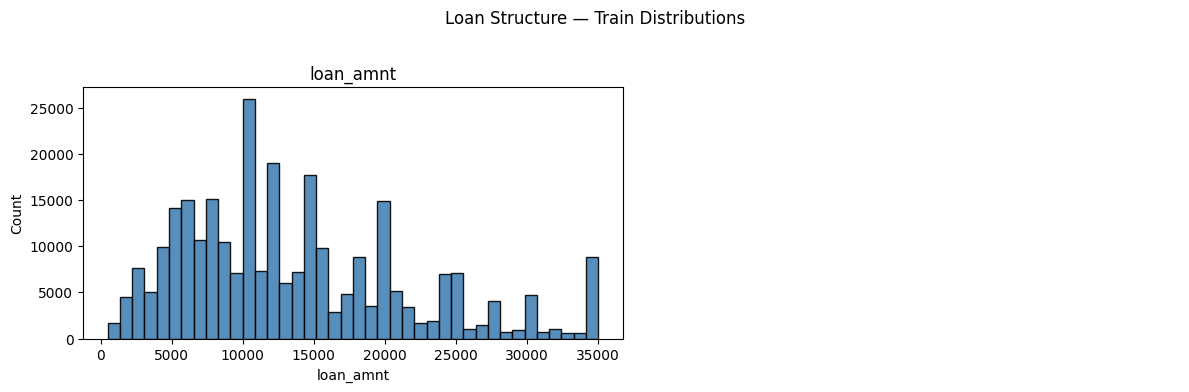

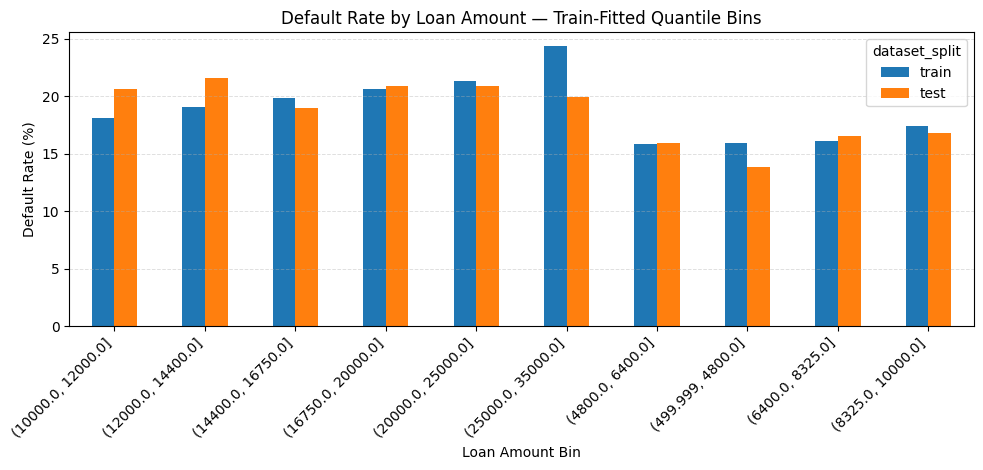

,feature_name,dataset_split,term_months,loan_count,default_rate_percent
0,term_months,train,36,219720,15.25
1,term_months,train,60,60476,31.54
2,term_months,test,36,42340,15.40
3,term_months,test,60,17672,26.31


,feature_name,dataset_split,purpose,loan_count,default_rate_percent
0,purpose,train,car,3914,12.42
1,purpose,train,credit_card,58312,16.07
2,purpose,train,debt_consolidation,163642,19.76
3,purpose,train,educational,325,17.23
4,purpose,train,home_improvement,16234,16.27
5,purpose,train,house,1658,18.70
6,purpose,train,major_purchase,6697,14.39
7,purpose,train,medical,3001,20.63
8,purpose,train,moving,2063,21.96
9,purpose,train,other,15185,21.30


In [ ]:
# --------------------------------------------------------
# Loan structure
# --------------------------------------------------------

loan_structure_numeric_columns = [
    "loan_amnt",
]

eda_fig.plot_numeric_distribution_grid(
    df=df_feature_base_train_terminal,
    column_names=loan_structure_numeric_columns,
    title="Loan Structure — Train Distributions",
    bins=40,
)

loan_amount_default_rate_df = ea.build_default_rate_by_train_fitted_quantile(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="loan_amnt",
)

eda_fig.plot_default_rate_comparison(
    loan_amount_default_rate_df,
    category_column="feature_bin",
    title="Default Rate by Loan Amount — Train-Fitted Quantile Bins",
    xlabel="Loan Amount Bin",
    rotate_labels=True,
)

term_default_rate_df = ea.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="term_months",
)

purpose_default_rate_df = ea.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="purpose",
)

display(term_default_rate_df)
display(purpose_default_rate_df)

loan_structure_tables_file = eda_tables_dir / "loan_structure_tables.csv"
pd.concat(
    [
        loan_amount_default_rate_df,
        term_default_rate_df.rename(columns={"term_months": "feature_bin"}),
        purpose_default_rate_df.rename(columns={"purpose": "feature_bin"}),
    ],
    axis=0,
    ignore_index=True,
).to_csv(loan_structure_tables_file, index=False)

log(f"[feature_base][loan_structure] tables_file={loan_structure_tables_file}")


### 2.4 Debt Burden

Debt-burden variables measure how much financial load the borrower already carries at the moment of application. This is one of the most important sections of the notebook because it speaks directly to repayment capacity.


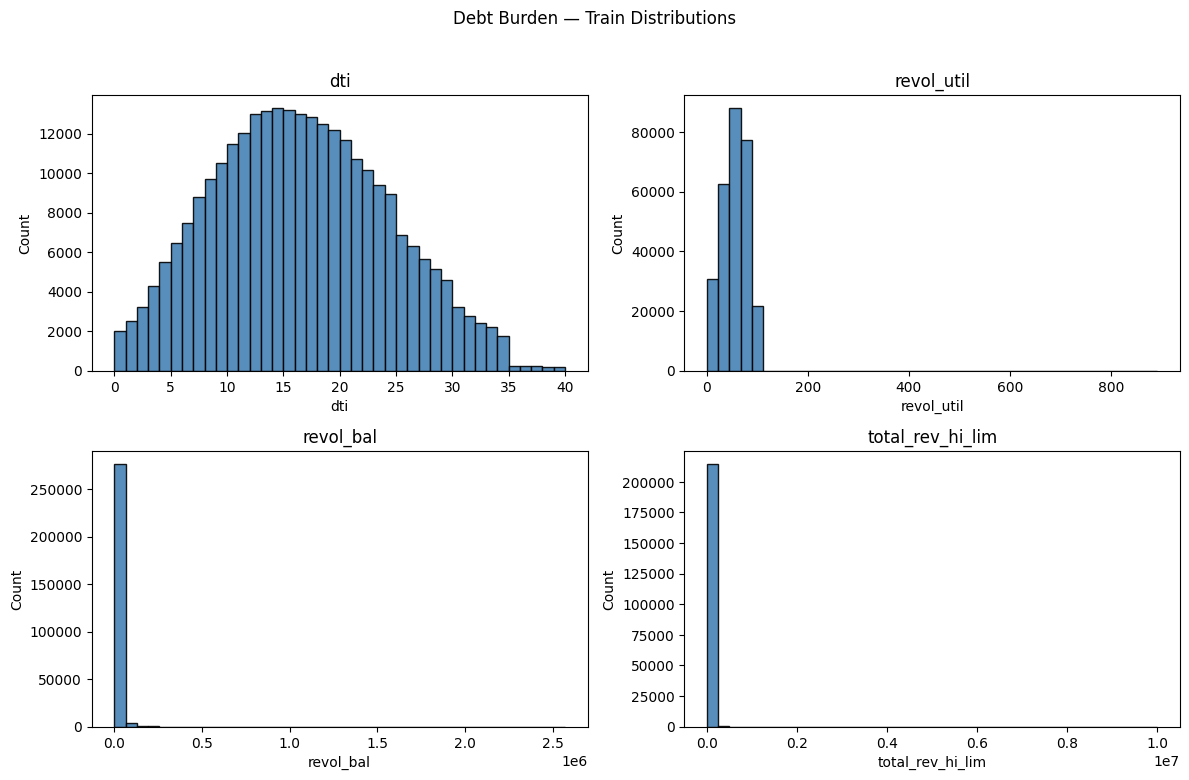

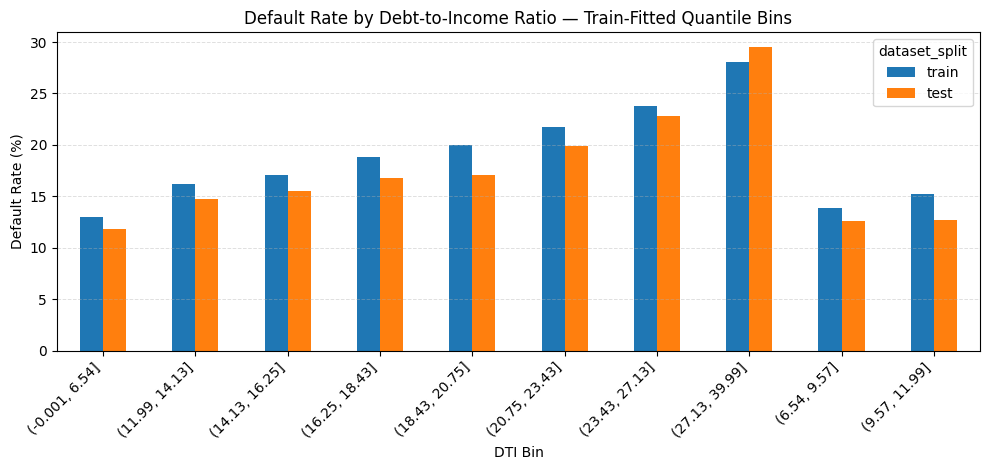

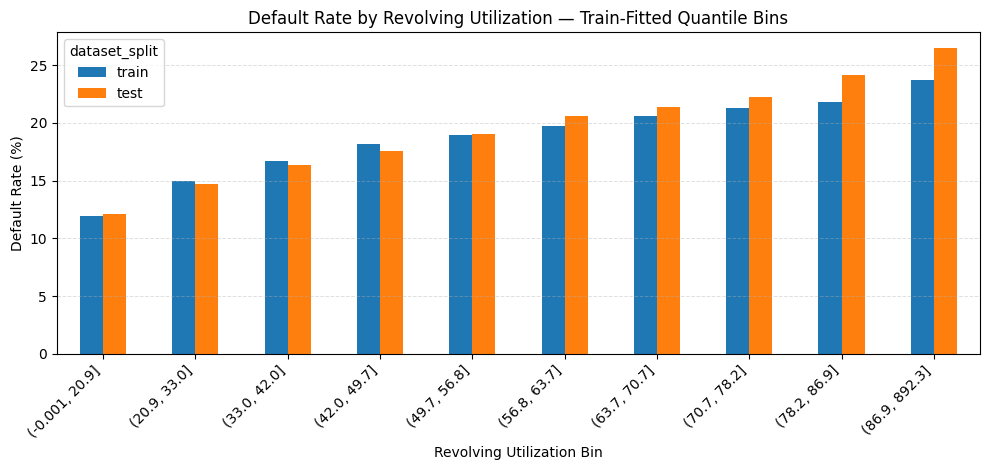

In [ ]:
# --------------------------------------------------------
# Debt burden
# --------------------------------------------------------

debt_burden_numeric_columns = [
    "dti",
    "revol_util",
    "revol_bal",
    "total_rev_hi_lim",
]

eda_fig.plot_numeric_distribution_grid(
    df=df_feature_base_train_terminal,
    column_names=debt_burden_numeric_columns,
    title="Debt Burden — Train Distributions",
    bins=40,
)

dti_default_rate_df = ea.build_default_rate_by_train_fitted_quantile(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="dti",
)

eda_fig.plot_default_rate_comparison(
    dti_default_rate_df,
    category_column="feature_bin",
    title="Default Rate by Debt-to-Income Ratio — Train-Fitted Quantile Bins",
    xlabel="DTI Bin",
    rotate_labels=True,
)

revol_util_default_rate_df = ea.build_default_rate_by_train_fitted_quantile(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="revol_util",
)

eda_fig.plot_default_rate_comparison(
    revol_util_default_rate_df,
    category_column="feature_bin",
    title="Default Rate by Revolving Utilization — Train-Fitted Quantile Bins",
    xlabel="Revolving Utilization Bin",
    rotate_labels=True,
)

debt_burden_tables_file = eda_tables_dir / "debt_burden_tables.csv"
pd.concat(
    [dti_default_rate_df, revol_util_default_rate_df],
    axis=0,
    ignore_index=True,
).to_csv(debt_burden_tables_file, index=False)

log(f"[feature_base][debt_burden] tables_file={debt_burden_tables_file}")


### 2.5 Credit History

Credit-history variables summarize the depth and condition of the borrower’s credit file. The question is whether longer and cleaner histories are associated with lower realized default rates.


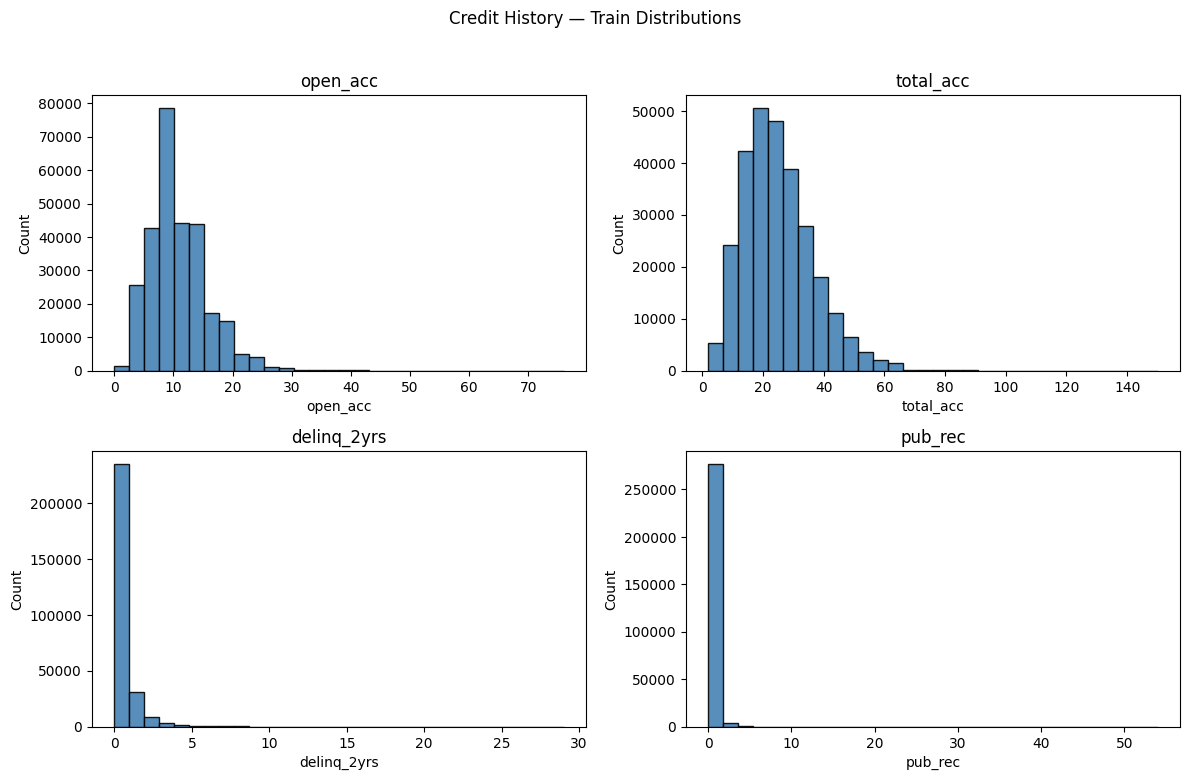

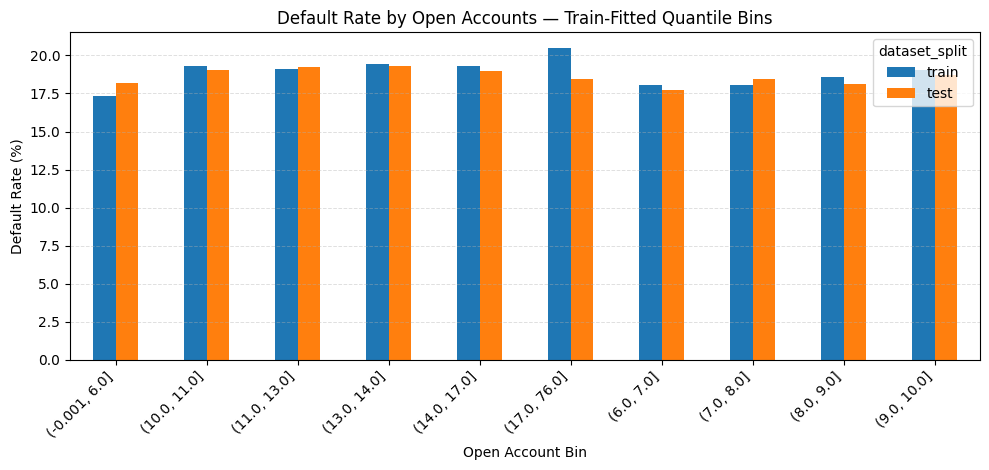

,feature_name,dataset_split,pub_rec,loan_count,default_rate_percent
0,pub_rec,train,0.0,246789,18.58
1,pub_rec,train,1.0,29597,19.91
2,pub_rec,train,10.0,7,0.00
3,pub_rec,train,11.0,2,0.00
4,pub_rec,train,13.0,1,0.00
5,pub_rec,train,2.0,2688,22.32
6,pub_rec,train,3.0,699,20.46
7,pub_rec,train,4.0,223,22.87
8,pub_rec,train,5.0,106,24.53
9,pub_rec,train,54.0,1,0.00


In [ ]:
# --------------------------------------------------------
# Credit history
# --------------------------------------------------------

credit_history_numeric_columns = [
    "open_acc",
    "total_acc",
    "delinq_2yrs",
    "pub_rec",
]

eda_fig.plot_numeric_distribution_grid(
    df=df_feature_base_train_terminal,
    column_names=credit_history_numeric_columns,
    title="Credit History — Train Distributions",
    bins=30,
)

open_acc_default_rate_df = ea.build_default_rate_by_train_fitted_quantile(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="open_acc",
)

eda_fig.plot_default_rate_comparison(
    open_acc_default_rate_df,
    category_column="feature_bin",
    title="Default Rate by Open Accounts — Train-Fitted Quantile Bins",
    xlabel="Open Account Bin",
    rotate_labels=True,
)

pub_rec_default_rate_df = ea.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="pub_rec",
)

display(pub_rec_default_rate_df)

credit_history_tables_file = eda_tables_dir / "credit_history_tables.csv"
pd.concat(
    [
        open_acc_default_rate_df,
        pub_rec_default_rate_df.rename(columns={"pub_rec": "feature_bin"}),
    ],
    axis=0,
    ignore_index=True,
).to_csv(credit_history_tables_file, index=False)

log(f"[feature_base][credit_history] tables_file={credit_history_tables_file}")


### 2.6 Recent Credit Behavior

Recent-credit-behavior variables capture short-horizon credit activity and the recency of adverse events. The purpose here is to determine whether recent strain or recent credit seeking is associated with materially higher realized default risk.


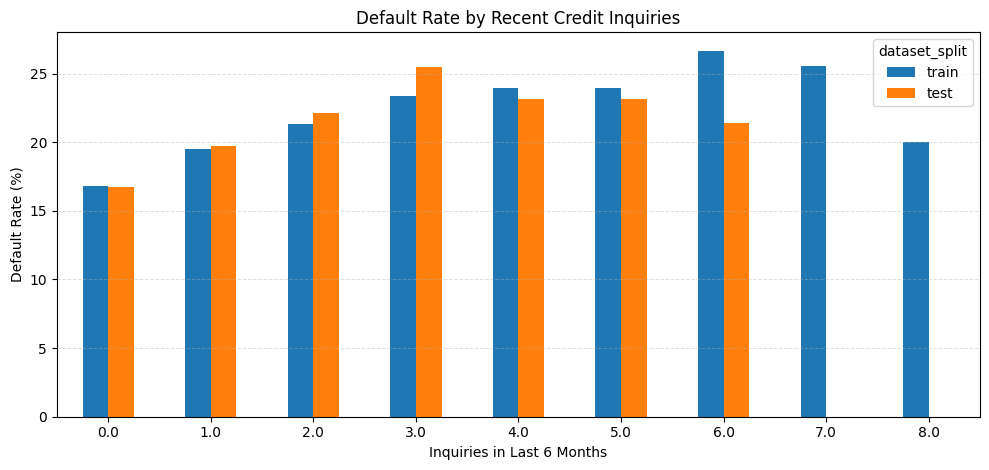

,feature_name,dataset_split,has_mths_since_last_delinq,loan_count,default_rate_percent
0,has_mths_since_last_delinq,train,0,156440,18.30
1,has_mths_since_last_delinq,train,1,123756,19.35
2,has_mths_since_last_delinq,test,0,29408,18.71
3,has_mths_since_last_delinq,test,1,30604,18.51


,feature_name,dataset_split,has_mths_since_last_major_derog,loan_count,default_rate_percent
0,has_mths_since_last_major_derog,train,0,227851,18.36
1,has_mths_since_last_major_derog,train,1,52345,20.52
2,has_mths_since_last_major_derog,test,0,42228,18.71
3,has_mths_since_last_major_derog,test,1,17784,18.37


,feature_name,dataset_split,has_mths_since_last_record,loan_count,default_rate_percent
0,has_mths_since_last_record,train,0,246119,18.58
1,has_mths_since_last_record,train,1,34077,20.09
2,has_mths_since_last_record,test,0,48535,18.67
3,has_mths_since_last_record,test,1,11477,18.35


In [ ]:
# --------------------------------------------------------
# Recent credit behavior
# --------------------------------------------------------

inquiries_default_rate_df = ea.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="inq_last_6mths",
)

eda_fig.plot_default_rate_comparison(
    inquiries_default_rate_df,
    category_column="inq_last_6mths",
    title="Default Rate by Recent Credit Inquiries",
    xlabel="Inquiries in Last 6 Months",
)

last_delinq_flag_default_rate_df = ea.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="has_mths_since_last_delinq",
)

last_major_derog_flag_default_rate_df = ea.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="has_mths_since_last_major_derog",
)

last_record_flag_default_rate_df = ea.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="has_mths_since_last_record",
)

display(last_delinq_flag_default_rate_df)
display(last_major_derog_flag_default_rate_df)
display(last_record_flag_default_rate_df)

recent_credit_behavior_tables_file = eda_tables_dir / "recent_credit_behavior_tables.csv"
pd.concat(
    [
        inquiries_default_rate_df.rename(columns={"inq_last_6mths": "feature_bin"}),
        last_delinq_flag_default_rate_df.rename(columns={"has_mths_since_last_delinq": "feature_bin"}),
        last_major_derog_flag_default_rate_df.rename(columns={"has_mths_since_last_major_derog": "feature_bin"}),
        last_record_flag_default_rate_df.rename(columns={"has_mths_since_last_record": "feature_bin"}),
    ],
    axis=0,
    ignore_index=True,
).to_csv(recent_credit_behavior_tables_file, index=False)

log(f"[feature_base][recent_credit_behavior] tables_file={recent_credit_behavior_tables_file}")


### 2.7 Reporting Shifts / Data Quality

The reporting-shift-sensitive balance variables identified in the clean dataset remain relevant in the feature base dataset, but they are no longer evaluated over time because `issue_d` is not retained here. The relevant question is whether missingness differs materially between train and test and whether the explicit missingness flags carry risk information.


In [ ]:
# --------------------------------------------------------
# Reporting shifts and data quality
# --------------------------------------------------------

feature_base_reporting_shift_columns = [
    "tot_coll_amt",
    "tot_cur_bal",
    "total_rev_hi_lim",
]

feature_base_missingness_summary_df = ea.build_feature_missingness_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    column_names=feature_base_reporting_shift_columns,
)

feature_base_missingness_summary_df["dataset_split"] = pd.Categorical(
    feature_base_missingness_summary_df["dataset_split"],
    categories=["train", "test"],
    ordered=True,
)

feature_base_missingness_summary_df = feature_base_missingness_summary_df.sort_values(
    ["dataset_split", "feature_name"]
).reset_index(drop=True)

display(feature_base_missingness_summary_df)

tot_cur_bal_missing_default_rate_df = ea.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="tot_cur_bal",
    treat_as_missingness=True,
)

total_rev_hi_lim_missing_default_rate_df = ea.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="total_rev_hi_lim",
    treat_as_missingness=True,
)

display(tot_cur_bal_missing_default_rate_df)
display(total_rev_hi_lim_missing_default_rate_df)

data_quality_tables_file = eda_tables_dir / "reporting_shift_data_quality_tables.csv"
pd.concat(
    [
        feature_base_missingness_summary_df.rename(columns={"feature_name": "feature_bin"}),
        tot_cur_bal_missing_default_rate_df.rename(columns={"tot_cur_bal_missing": "feature_bin"}),
        total_rev_hi_lim_missing_default_rate_df.rename(columns={"total_rev_hi_lim_missing": "feature_bin"}),
    ],
    axis=0,
    ignore_index=True,
).to_csv(data_quality_tables_file, index=False)

log(f"[feature_base][data_quality] tables_file={data_quality_tables_file}")


,feature_name,dataset_split,missing_percent
0,tot_coll_amt,train,23.4
1,tot_cur_bal,train,23.4
2,total_rev_hi_lim,train,23.4
3,tot_coll_amt,test,0.0
4,tot_cur_bal,test,0.0
5,total_rev_hi_lim,test,0.0


,feature_name,dataset_split,category,loan_count,default_rate_percent
0,tot_cur_bal,train,missing,65561,15.54
1,tot_cur_bal,train,not_missing,214635,19.75
2,tot_cur_bal,test,not_missing,60012,18.61


,feature_name,dataset_split,category,loan_count,default_rate_percent
0,total_rev_hi_lim,train,missing,65561,15.54
1,total_rev_hi_lim,train,not_missing,214635,19.75
2,total_rev_hi_lim,test,not_missing,60012,18.61


#### 2.8 Decision EDA Summary — Submission-Time Feature Behavior

The feature-base analysis shows that the submission-time feature space contains observable differences in default outcomes without relying on post-origination information. Borrower profile, loan design, leverage, credit-file depth, recent credit activity, and explicit missingness all produce systematic variation in default rates.

The important point is not that every variable is equally predictive. Rather, multiple dimensions of borrower and loan characteristics display economically plausible differences in repayment outcomes. These patterns are consistent with the mechanisms typically associated with consumer credit risk.

Taken together, the results indicate that the information available at loan application contains sufficient structure to support predictive modeling under the submission-time constraint.

---

## Part 2 Conclusion

The feature-level analysis examines the information available at the moment a borrower applies for a loan and evaluates how that information corresponds to observed differences in default rates. Several patterns emerge consistently across the feature groups. Variables describing existing credit obligations and past credit behavior show the strongest differences in default outcomes. Measures of leverage and credit utilization are generally associated with higher default rates, while indicators of established credit history correspond with lower risk.

Borrower profile variables such as income and employment characteristics also display variation in default rates, although the differences are typically less pronounced. These attributes describe repayment capacity but do not fully capture how borrowers manage their existing credit obligations, so they provide contextual information without dominating the predictive signal.

Loan structure variables introduce an additional dimension. Interest rates and contractual loan characteristics partly reflect LendingClub’s internal underwriting decisions. Their relationship with default risk therefore contains both borrower information and the platform’s attempt to price that risk. This observation connects directly to the central analytical question of the project: whether a model built using the same application-time information can reproduce or improve the ordering implied by LendingClub’s grading system.

Overall, the submission-time feature space exhibits several economically plausible sources of variation in default risk. Taken together, these results indicate that the information available at loan application contains sufficient structure to support predictive modeling. The next stage evaluates how accurately these relationships can be captured using formal predictive models.

---

In [21]:
# Creating portfolio evolution figure artifact
issuance_volume_by_issue_year_table = pd.read_csv(
    eda_tables_dir / "clean_issuance_volume_by_issue_year.csv"
)

default_rate_by_issue_year_table = pd.read_csv(
    eda_tables_dir / "clean_default_rate_by_issue_year.csv"
)

{
    "issuance_volume_rows": issuance_volume_by_issue_year_table.shape[0],
    "default_rate_rows": default_rate_by_issue_year_table.shape[0],
}

portfolio_evolution_figure_path = eda_figures_dir / "portfolio_evolution.png"

artifact_output_path = rf.plot_portfolio_evolution_figure(
    issuance_volume_table=issuance_volume_by_issue_year_table,
    default_rate_table=default_rate_by_issue_year_table,
    output_path=portfolio_evolution_figure_path,
    log=PROJECT_LOG_FILE,
)

{
    "eda_artifact_path": str(artifact_output_path)
}

{'eda_artifact_path': 'D:\\Portfolio\\loans-at-risk-capturing-default\\artifacts\\eda\\figures\\portfolio_evolution.png'}

## Notebook Conclusion

The diagnostic stage confirms that the LendingClub dataset provides a coherent representation of the lending process. Repayment outcomes can be defined using completed loan states, the temporal structure of the data supports a realistic train–test evaluation design, and reporting shifts affecting several balance variables have been identified and documented. These findings establish that the dataset can be used for predictive analysis without relying on information that would not have been available at the moment of loan application.

The submission-time feature space also shows systematic differences in borrower default outcomes. Variables describing leverage, credit utilization, and historical repayment behavior display the strongest variation in default rates. Borrower profile characteristics provide additional context about repayment capacity, while loan structure variables reflect the platform’s own attempt to price borrower risk through interest rates and contract terms.

Three conclusions follow from these observations: 
- 1. The dataset represents a stable lending environment with consistent default behavior across the evaluation window. 
- 2. The information available at application submission contains multiple sources of risk differentiation, particularly in borrower leverage and credit history. 
- 3. The feature space allows a direct comparison between LendingClub’s existing grading system and model-based estimates of borrower risk.

The next stage moves from exploratory analysis to predictive modeling. Using only the submission-time information defined in this notebook, the modeling phase evaluates how accurately borrower default risk can be predicted and whether a statistical model can reproduce or improve the risk ordering implied by LendingClub’s grading system.